## Gravitational Waves Signal
-- Sagnik Bhowmick


### Introduction

In this notebook we will read and visualize one of the gravitational wave signals detected by LIGO and define a straight line that fits a dataset.


## Obtaining the Gravitational Wave signal

Obtaining short segments of data from the [Gravitational Wave Open Science Center](https://www.gw-openscience.org)


The first step is to set the GPS time (t0) of the signal and choosing the detector.

The detectors are

- H1 : Hanford
- L1 : Livingstone
- V1 : VIRGO

Complete information about events is available at [https://www.gw-openscience.org/eventapi/](https://www.gw-openscience.org/eventapi/)


In [30]:
# installing necessary libraries
!pip install gwpy

In [38]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'


import requests, os
from gwpy.timeseries import TimeSeries
from gwosc.locate import get_urls

# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Set a GPS time:
t0 = 1126259462.4    # -- Signal GW150914


Now, we will query and download the .hdf5 file from H1 detector

In [46]:
# -- Download H1 (Hanford) data
detector = 'H1'
url = get_urls(detector, t0, t0)[-1]
print('Downloading: ', url)
file_H1 = 'data/' + os.path.basename(url)
with open(file_H1, 'wb') as strainfile:                 
    straindata = requests.get(url)
    strainfile.write(straindata.content)

Downloading:  https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/H-H1_GWOSC_4KHZ_R1-1126257415-4096.hdf5


Now let us download the same dataset but from  detector L1,

In [48]:
# -- Download L1 (Livingston) data
detector = 'L1'
url = get_urls(detector, t0, t0)[-1]
print('Downloading: ', url)
file_L1 = 'data/' + os.path.basename(url)
with open(file_L1, 'wb') as strainfile:                 
    straindata = requests.get(url)
    strainfile.write(straindata.content)

Downloading:  https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/L-L1_GWOSC_4KHZ_R1-1126257415-4096.hdf5


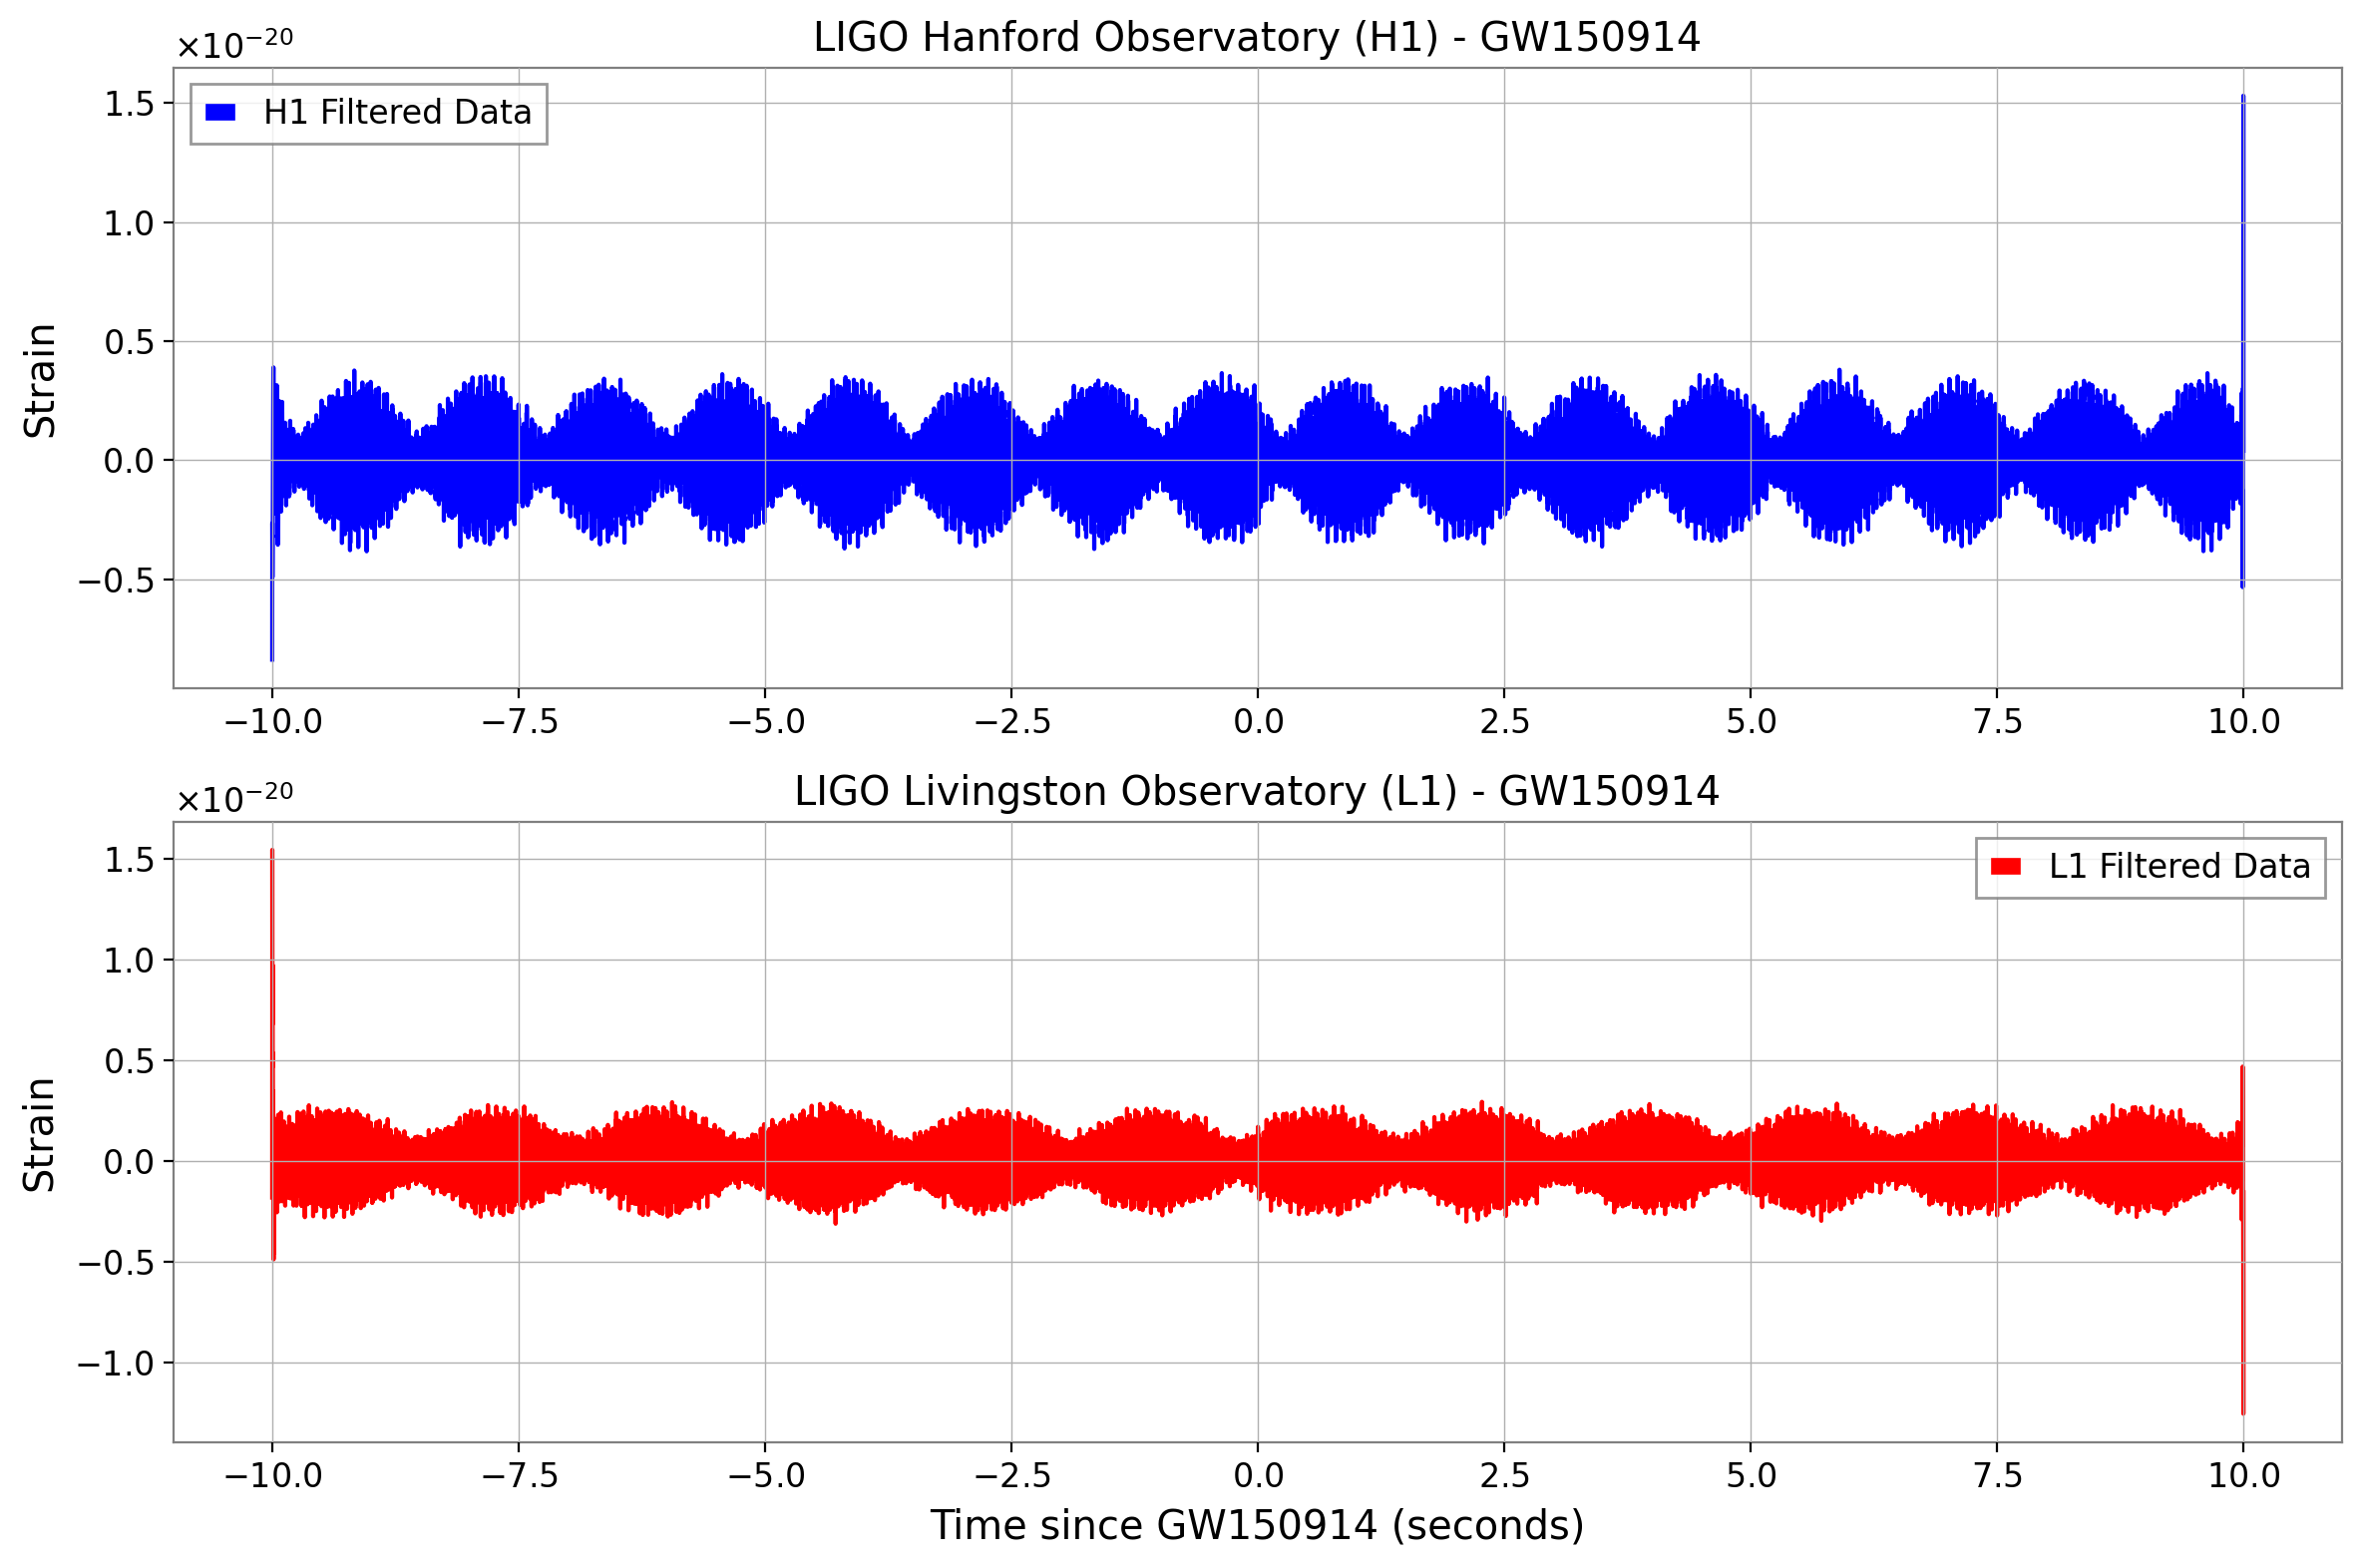

In [51]:
# Read the strain data from both detectors
strain_H1 = TimeSeries.read(file_H1, format='hdf5.gwosc')
strain_L1 = TimeSeries.read(file_L1, format='hdf5.gwosc')

# Set the time window around the event
deltat = 10  # seconds around the event
# GPS time window
starttime = t0 - deltat
endtime = t0 + deltat

# Crop the data to the relevant time window
strain_H1 = strain_H1.crop(starttime, endtime)
strain_L1 = strain_L1.crop(starttime, endtime)

# Apply bandpass filter to focus on the frequency range of interest (35-350 Hz)
strain_H1_filt = strain_H1.bandpass(35, 350)
strain_L1_filt = strain_L1.bandpass(35, 350)

# Plotting
plt.figure(figsize=(12, 8))

# Convert to numpy arrays for plotting and remove units
times_H1 = strain_H1_filt.times.value - t0  # Get the raw value without units
values_H1 = strain_H1_filt.value
times_L1 = strain_L1_filt.times.value - t0
values_L1 = strain_L1_filt.value

# Plot H1 detector data
plt.subplot(2, 1, 1)
plt.plot(times_H1, values_H1, 'b', label='H1 Filtered Data')
plt.grid(True)
plt.ylabel('Strain')
plt.legend()
plt.title('LIGO Hanford Observatory (H1) - GW150914')

# Plot L1 detector data
plt.subplot(2, 1, 2)
plt.plot(times_L1, values_L1, 'r', label='L1 Filtered Data')
plt.grid(True)
plt.xlabel('Time since GW150914 (seconds)')
plt.ylabel('Strain')
plt.legend()
plt.title('LIGO Livingston Observatory (L1) - GW150914')

plt.tight_layout()
plt.savefig('GW150914_signal.png', dpi=300)
plt.show()

### Plot the Amplitude Spectral Density (ASD)

Plotting these data in the Fourier domain gives us an idea of the frequency content of the data. 

A way to visualize the frequency content is to plot the **A**mplitude **S**pectral **D**ensity (**ASD**), i.e. the square root of the **P**ower **S**pectral **D**ensity (**PSD**), which is the average of the square of the **F**ast **F**ourier **T**ransform (FFT) of the data.

The ASD is an estimate of the "strain-equivalent noise" of the detectors versus frequency, which limit the ability of the detectors to identify GW signals. It is measured  in units of strain/rt(Hz). 

To obtain the root-mean-square strain noise in some frequency band,we must integrate the squares of the ASD over that band and then take the square-root.

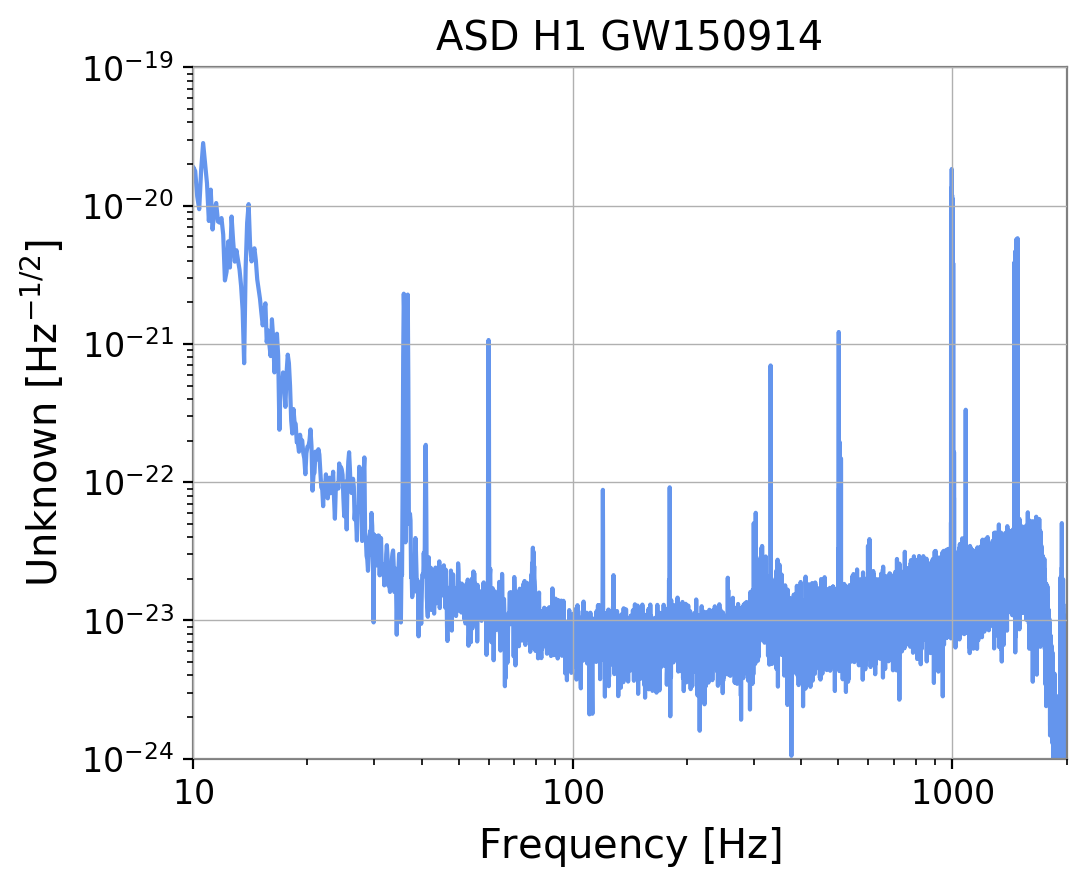

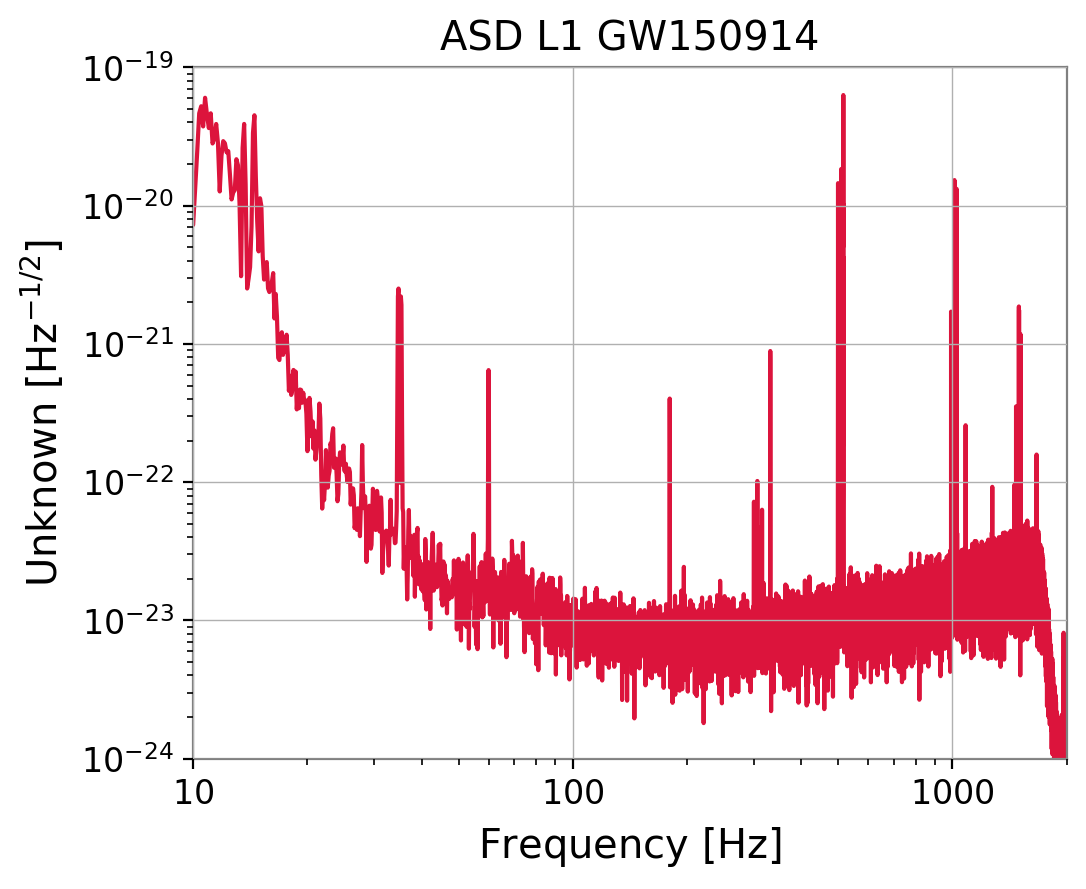

In [55]:
# Plot ASD

fig1 = strain_H1.asd(fftlength=8).plot(color='cornflowerblue')
plt.title('ASD H1 GW150914')
plt.xlim(10,2000)
plt.ylim(1e-24, 1e-19)


fig2 = strain_L1.asd(fftlength=8).plot(color='crimson')
plt.title('ASD L1 GW150914')
plt.xlim(10,2000)
plt.ylim(1e-24, 1e-19)
plt.show()

In these plots we only consider frequencies between $f_{min} = 20$ Hz and $f_{max} = 2000$ Hz.

Below $f_{min}$ the data are not properly calibrated (the noise is so high that LIGO cannot sense gravitational wave strain from astrophysical sources below this value). On the other hand, the sample rate of this event is $f_s = 4096$ Hz (i.e. $2^{12}$ Hz). Hence, the data cannot capture frequency content above the *Nyquist frequency*, defined as $f_N = \frac{fs}{2} = 2048$ Hz. 

From the plots, it is easy to see strong spectral lines in the data. These have an instrumental origin as for example that corresponding to the detectors, which are suspended mirrors with resonances at $~500$ Hz (and harmonics).

The ASD figure does not show the GW signal because it is relatively weak and less than a second long and the plot averages over 32 seconds. In fact, this plot is entirely dominated by instrumental noise.

### Plot a q-transform of the data

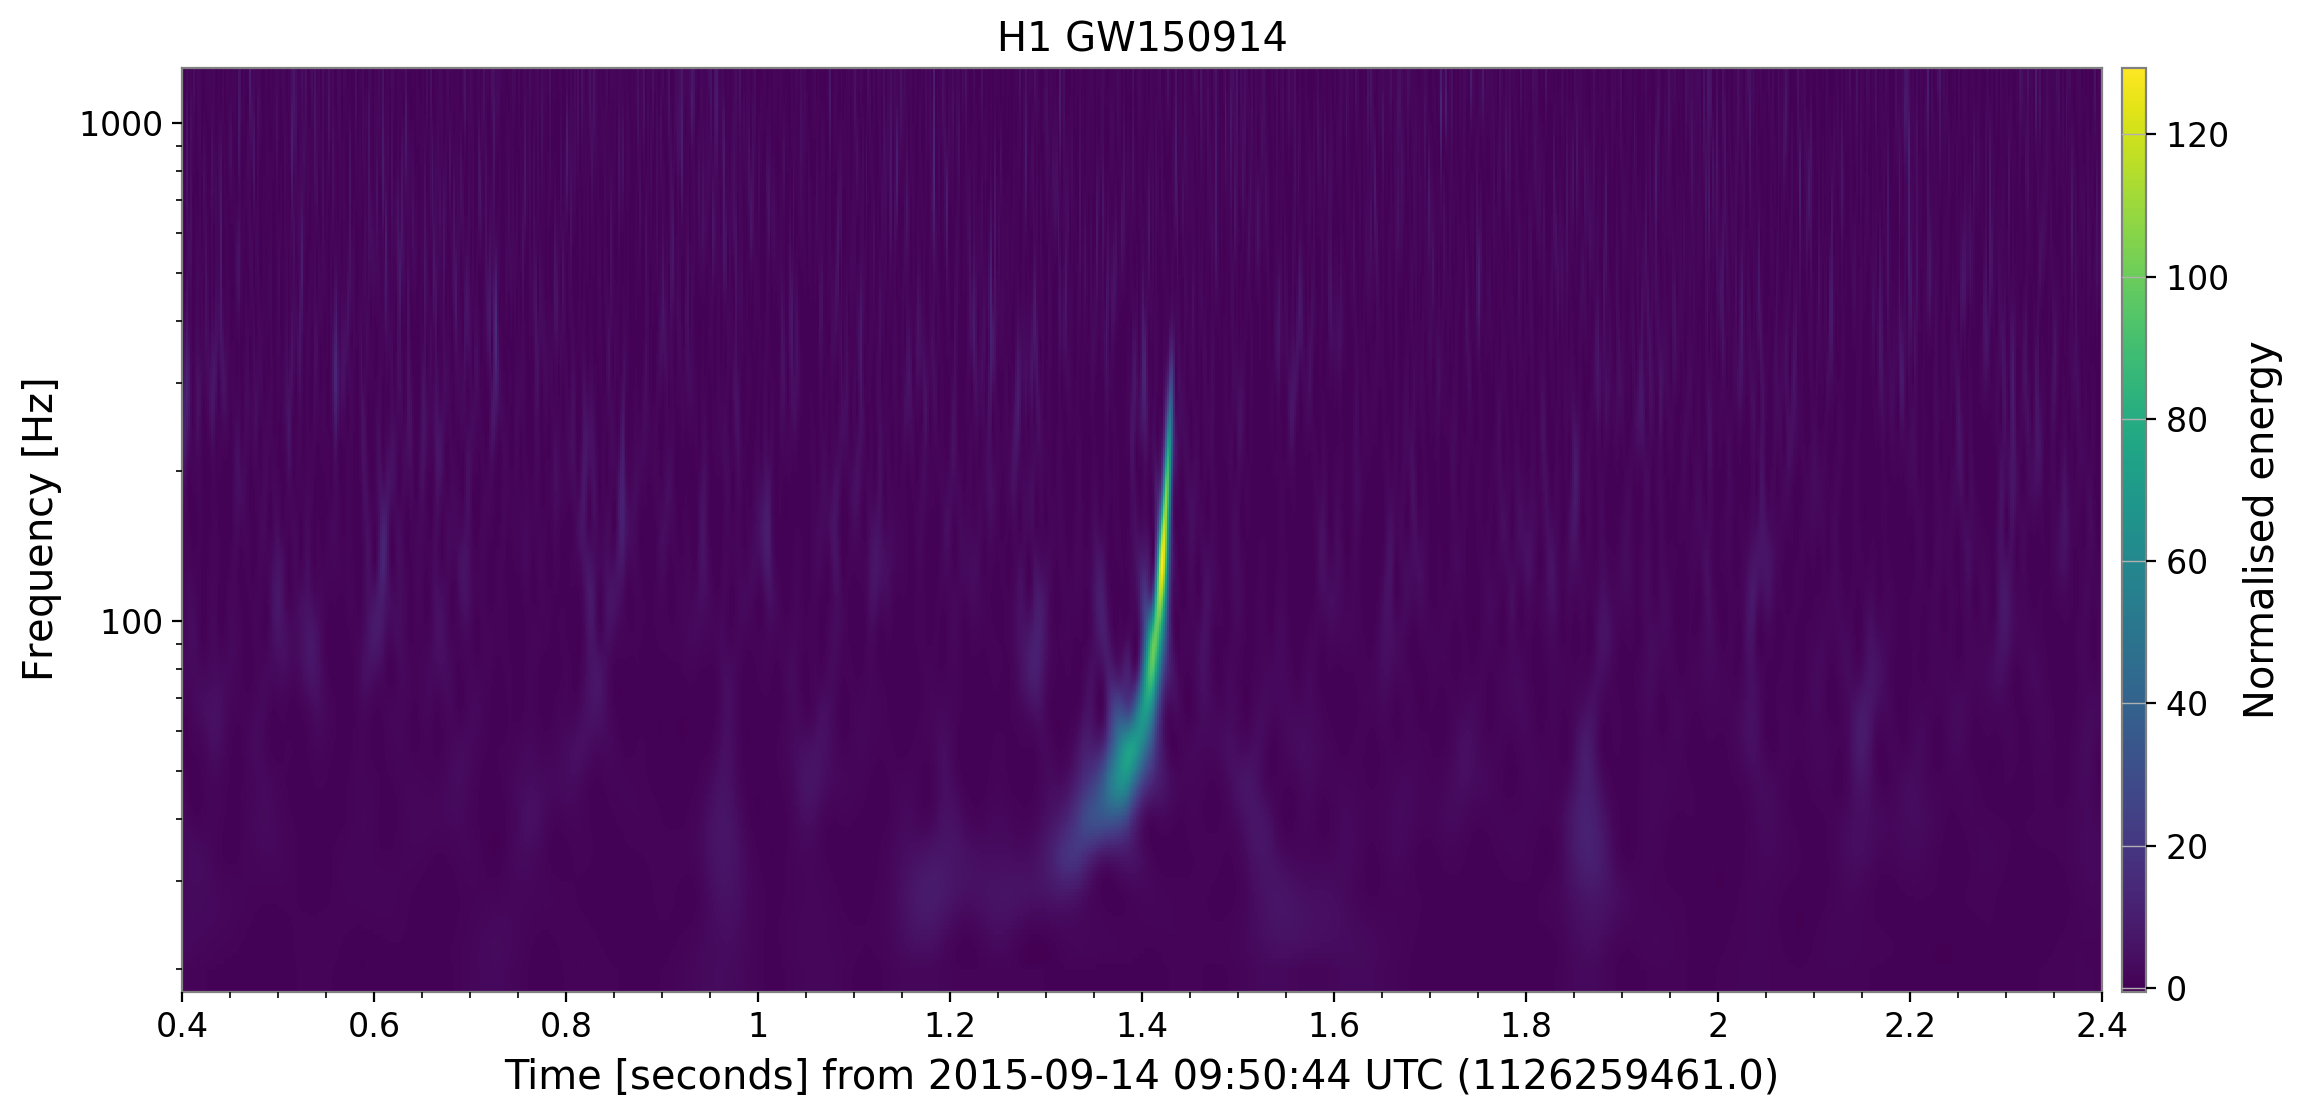

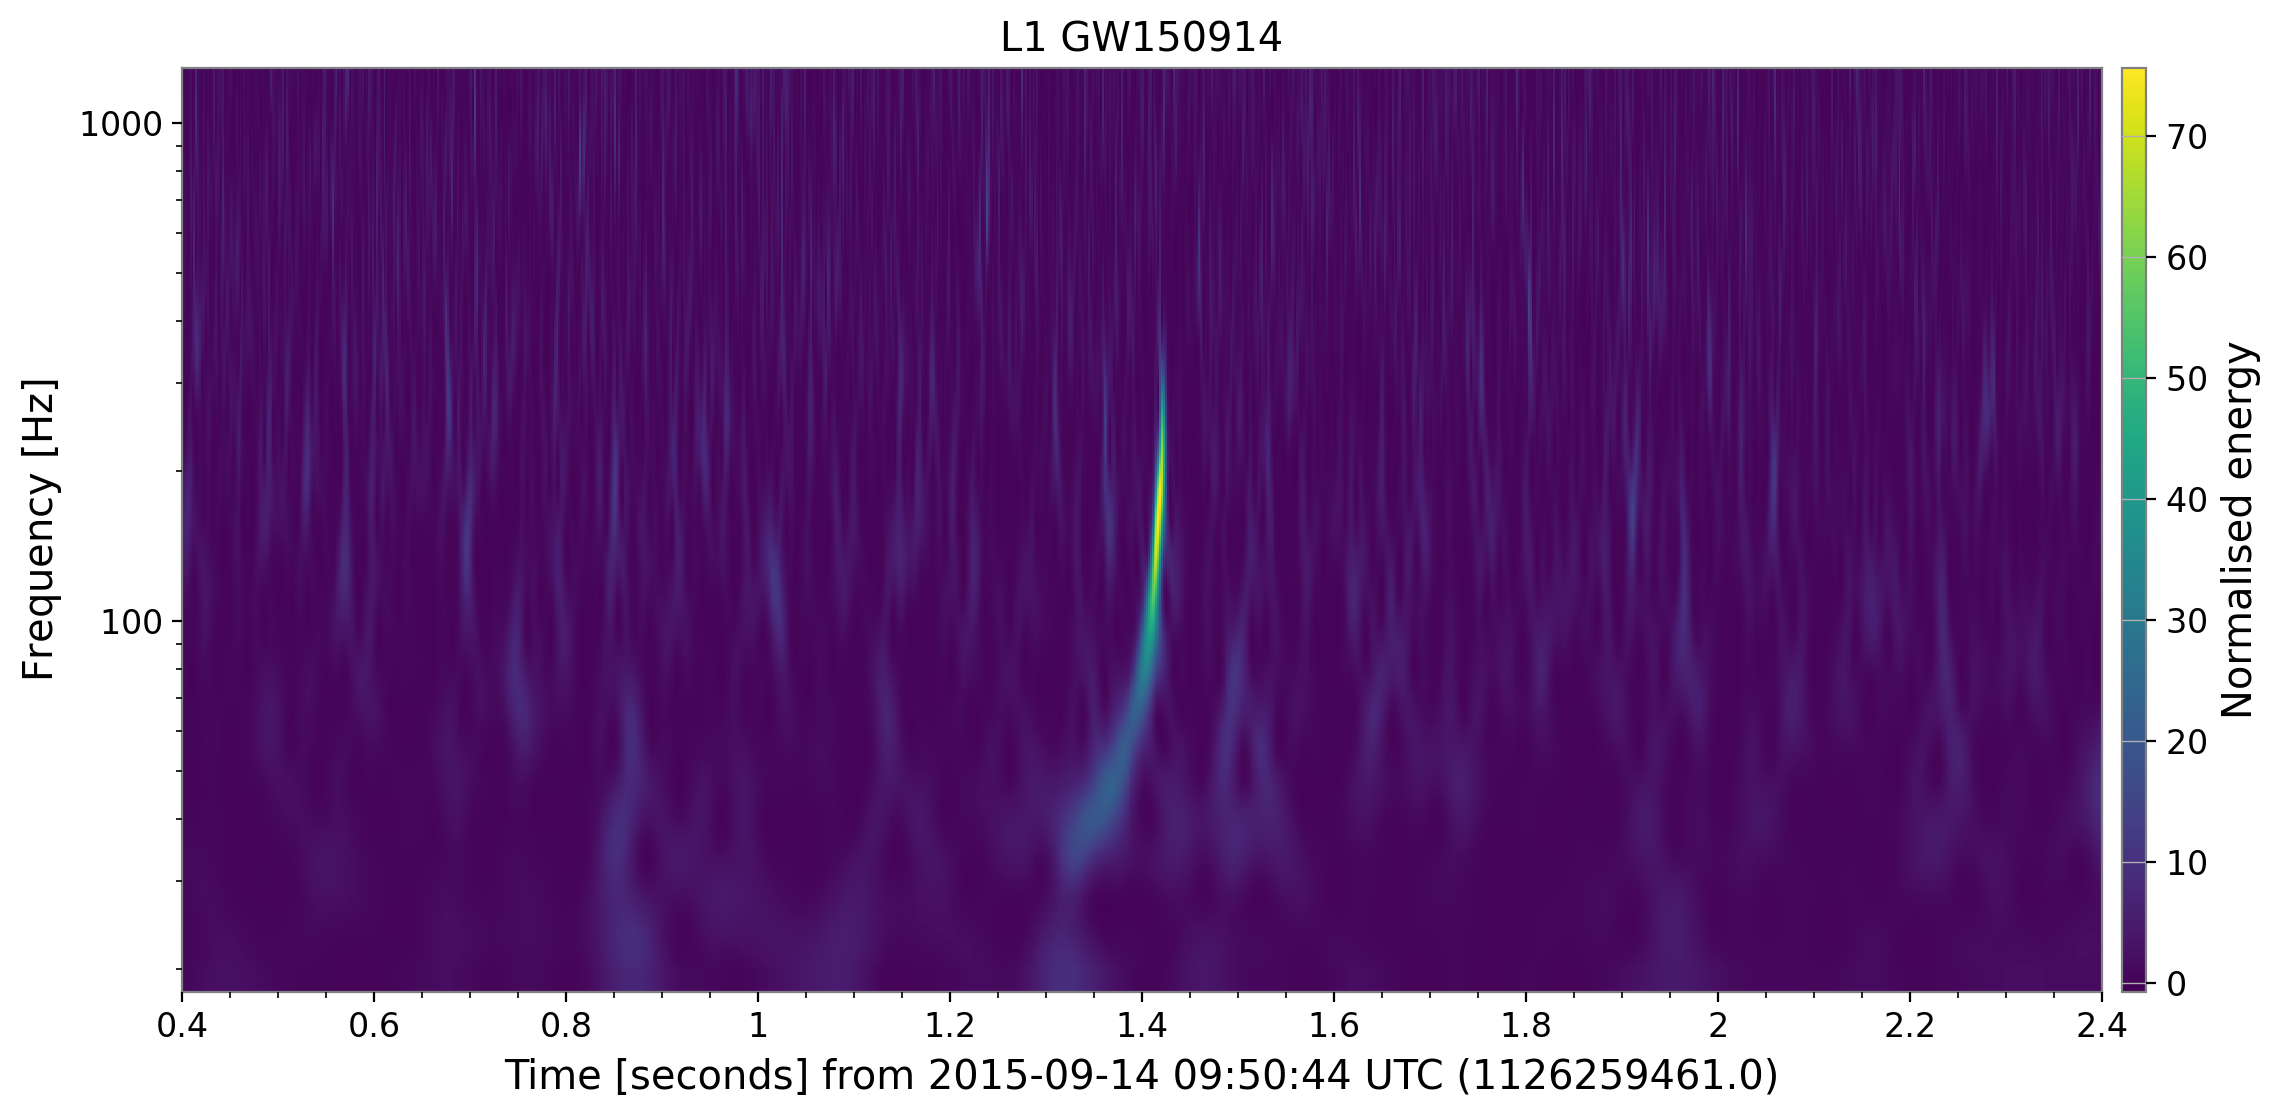

In [57]:
dt = 1  # Set width of q-transform plot, in seconds
hq_H1 = strain_H1.q_transform(outseg=(t0-dt, t0+dt))
fig1 = hq_H1.plot()
ax = fig1.gca()
fig1.colorbar(label="Normalised energy")
ax.grid(False)
ax.set_yscale('log')
ax.set_title('H1 GW150914')


dt = 1  # Set width of q-transform plot, in seconds
hq_L1 = strain_L1.q_transform(outseg=(t0-dt, t0+dt))
fig2 = hq_L1.plot()
ax = fig2.gca()
fig2.colorbar(label="Normalised energy")
ax.grid(False)
ax.set_yscale('log')
ax.set_title('L1 GW150914')

plt.show()

### Power Spectral Density (PSD) Calculation:

Crops data from both LIGO detectors (H1 = Hanford, L1 = Livingston) from a period before the event
Calculates the PSD to see the distribution of noise power across different frequencies
Converts this to Amplitude Spectral Density (ASD) by taking the square root


### Background ASD Plot:

Creates a logarithmic plot showing the noise amplitude vs. frequency for both detectors
Annotates known noise sources in the detectors:

Seismic noise (low frequencies ~20 Hz)
Thermal noise (mid frequencies ~100 Hz)
Quantum noise (higher frequencies ~500 Hz)


This plot helps understand the detector sensitivity at different frequencies

### Spectrogram Analysis
Next, the code creates spectrograms to visualize how the signal evolves in both time and frequency:

Time-Frequency Analysis:

Creates spectrograms using short-time Fourier transforms
Shows how the frequency content changes over time around the event
Uses a logarithmic color scale to show strain amplitude


### Spectrogram Plots:

Creates two plots (one for each detector) showing frequency vs. time
Centers the plot window on the event time (t0)
The color indicates the strength of signal at each time-frequency point
These spectrograms help visualize the "chirp" pattern characteristic of merging black holes


### Q-Transform Analysis
The code attempts a more specialized time-frequency analysis using Q-transforms:

### Q-Transform Calculation:

More specialized than spectrograms for gravitational wave analysis
Focuses on frequencies between 20-500 Hz where the signal is expected
Has better time-frequency resolution for the specific signals of interest


### Q-Transform Plots:

Similar to spectrograms but with better resolution for transient signals
Uses a very tight time window (t0 ± 0.2s) to focus precisely on the event
Shows the frequency evolution in greater detail, which should reveal the characteristic "chirp" pattern (increasing frequency and amplitude)


### Signal-to-Noise Ratio (SNR) Calculation
The code estimates how strong the signal is compared to the background noise:

### SNR Calculation:

Compares filtered signal during the event to filtered background noise
Uses root-mean-square (RMS) values to calculate the ratio
Prints the estimated SNR value


### Detector Coherence Analysis
Finally, the code analyzes how correlated the noise is between the two detectors:

### Coherence Calculation:

Measures correlation between the two detectors in the frequency domain
Uses data from before the event to focus on noise characteristics
Values range from 0 (no correlation) to 1 (perfect correlation)


### Coherence Plot:

Shows correlation vs. frequency between H1 and L1 detectors
Identifies frequencies with high coherence (above 0.5)
High coherence at specific frequencies could indicate common noise sources affecting both detectors

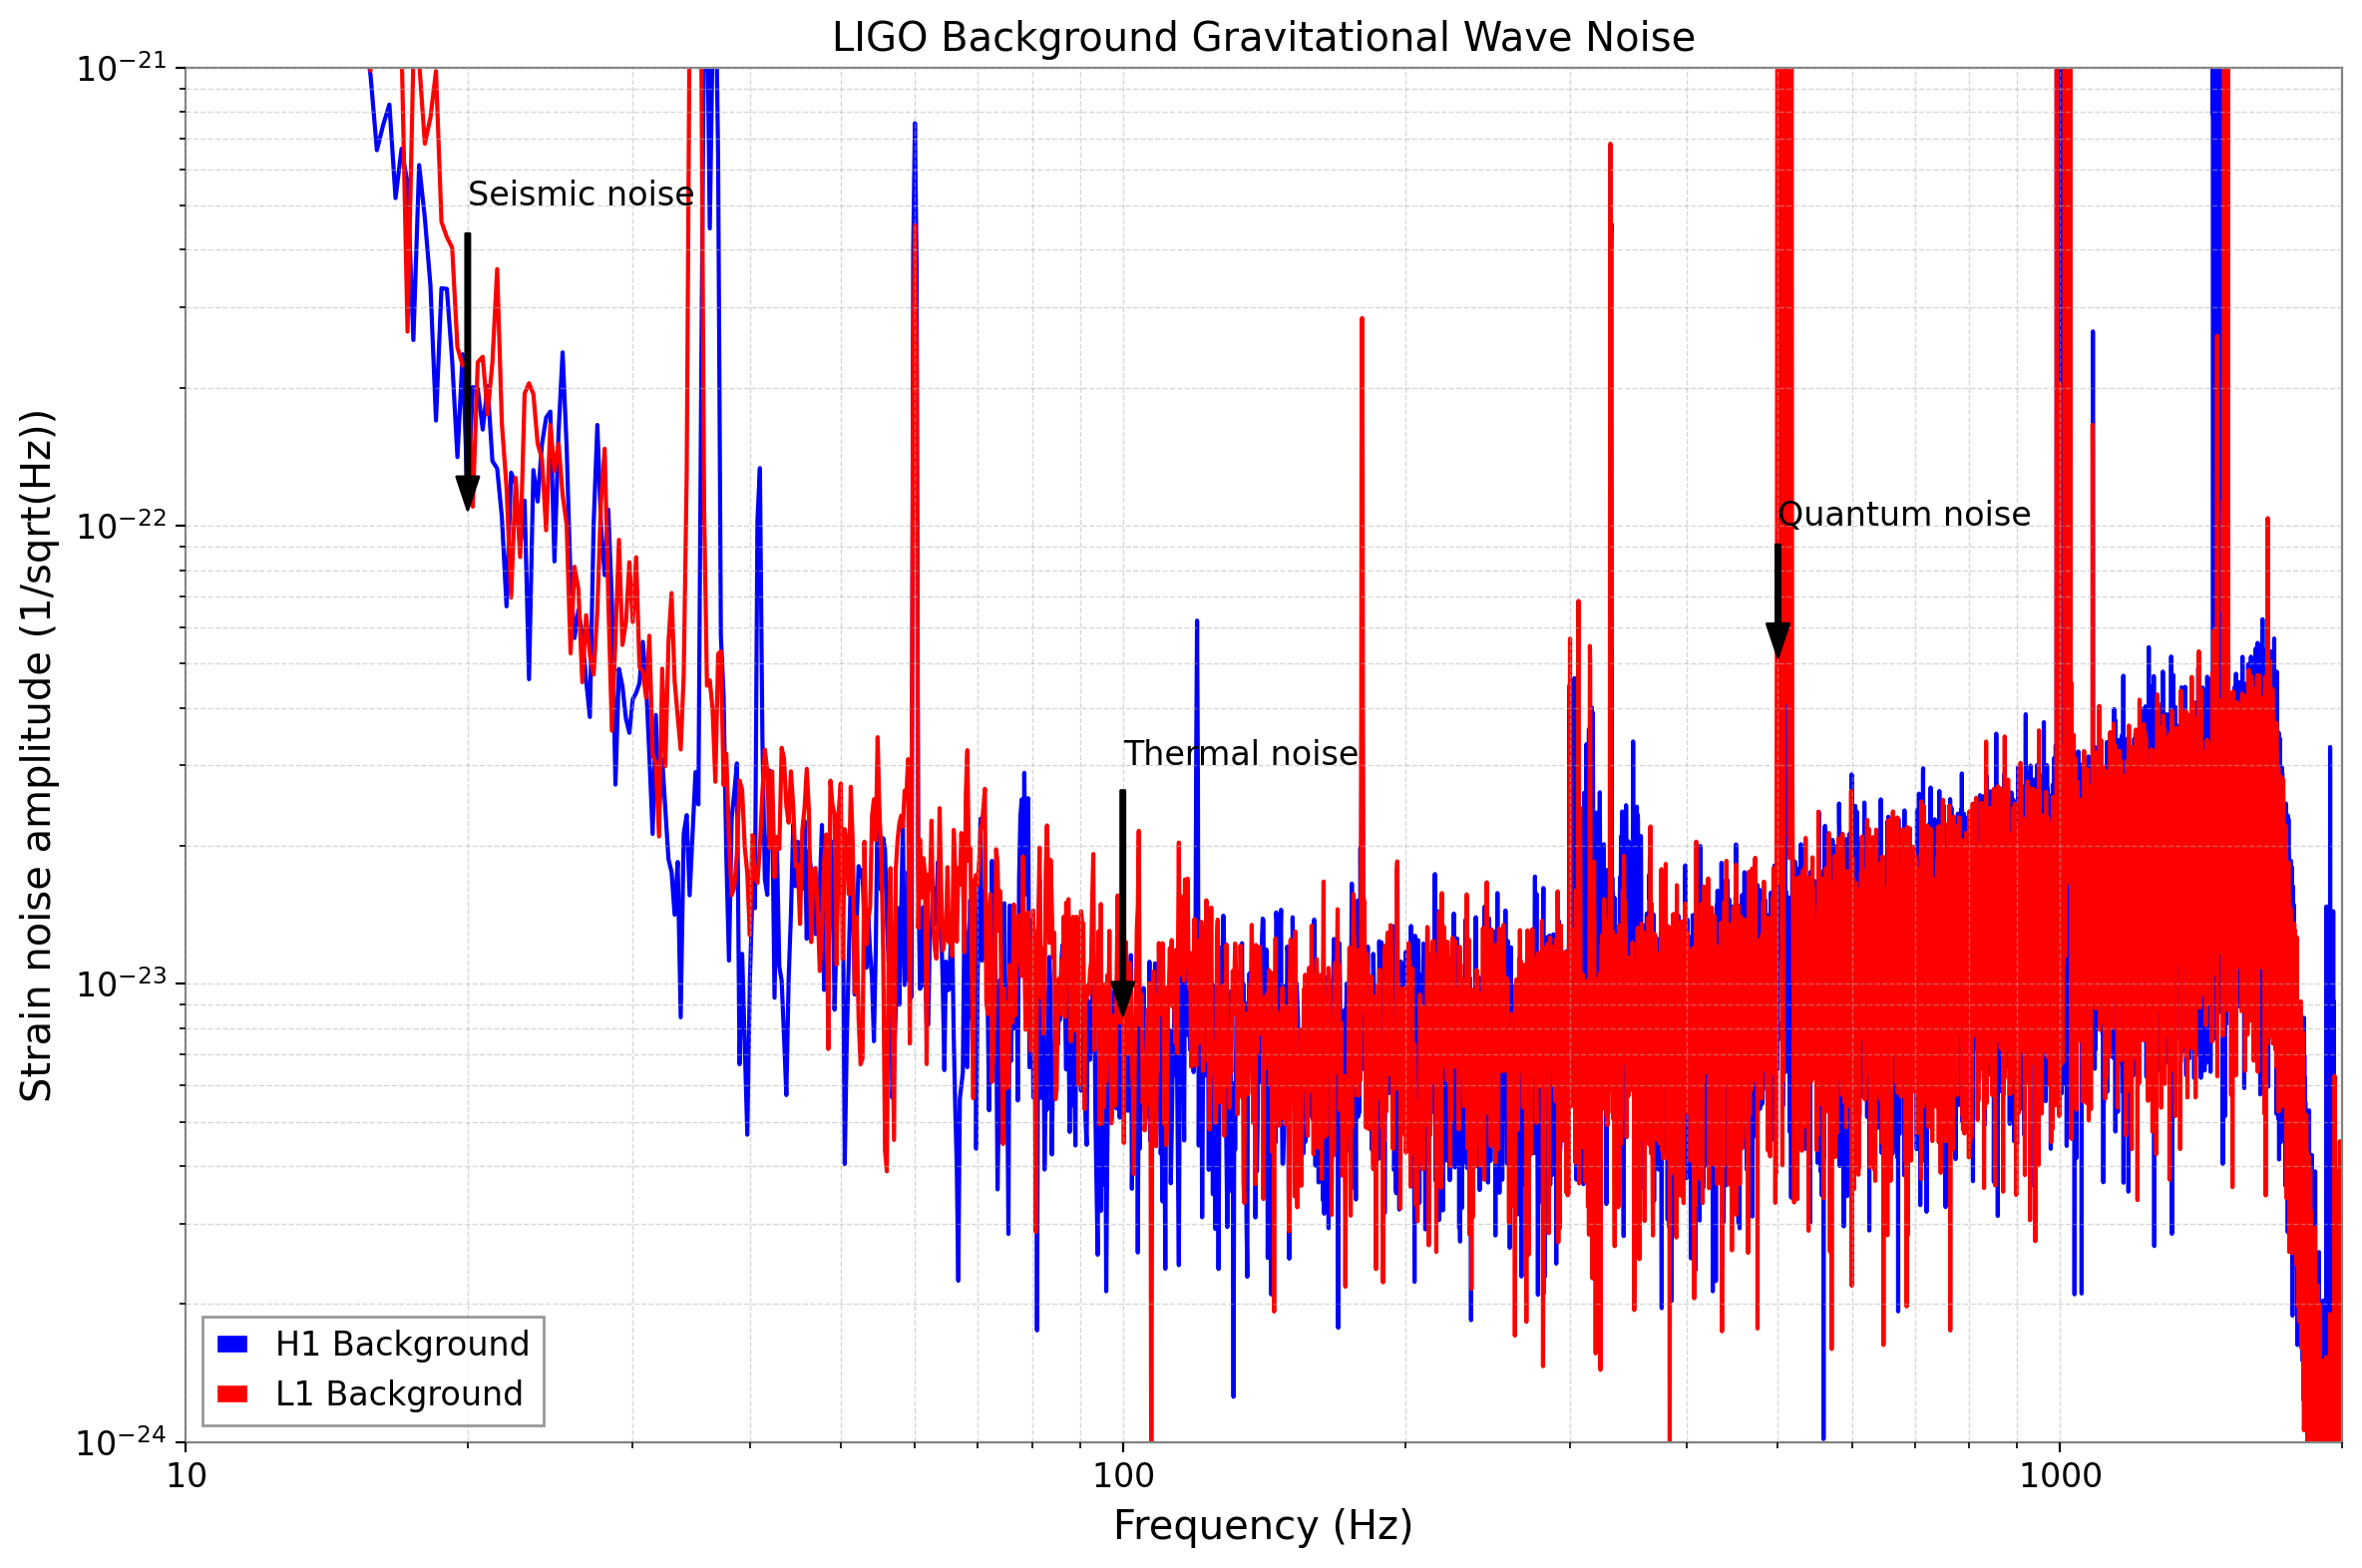

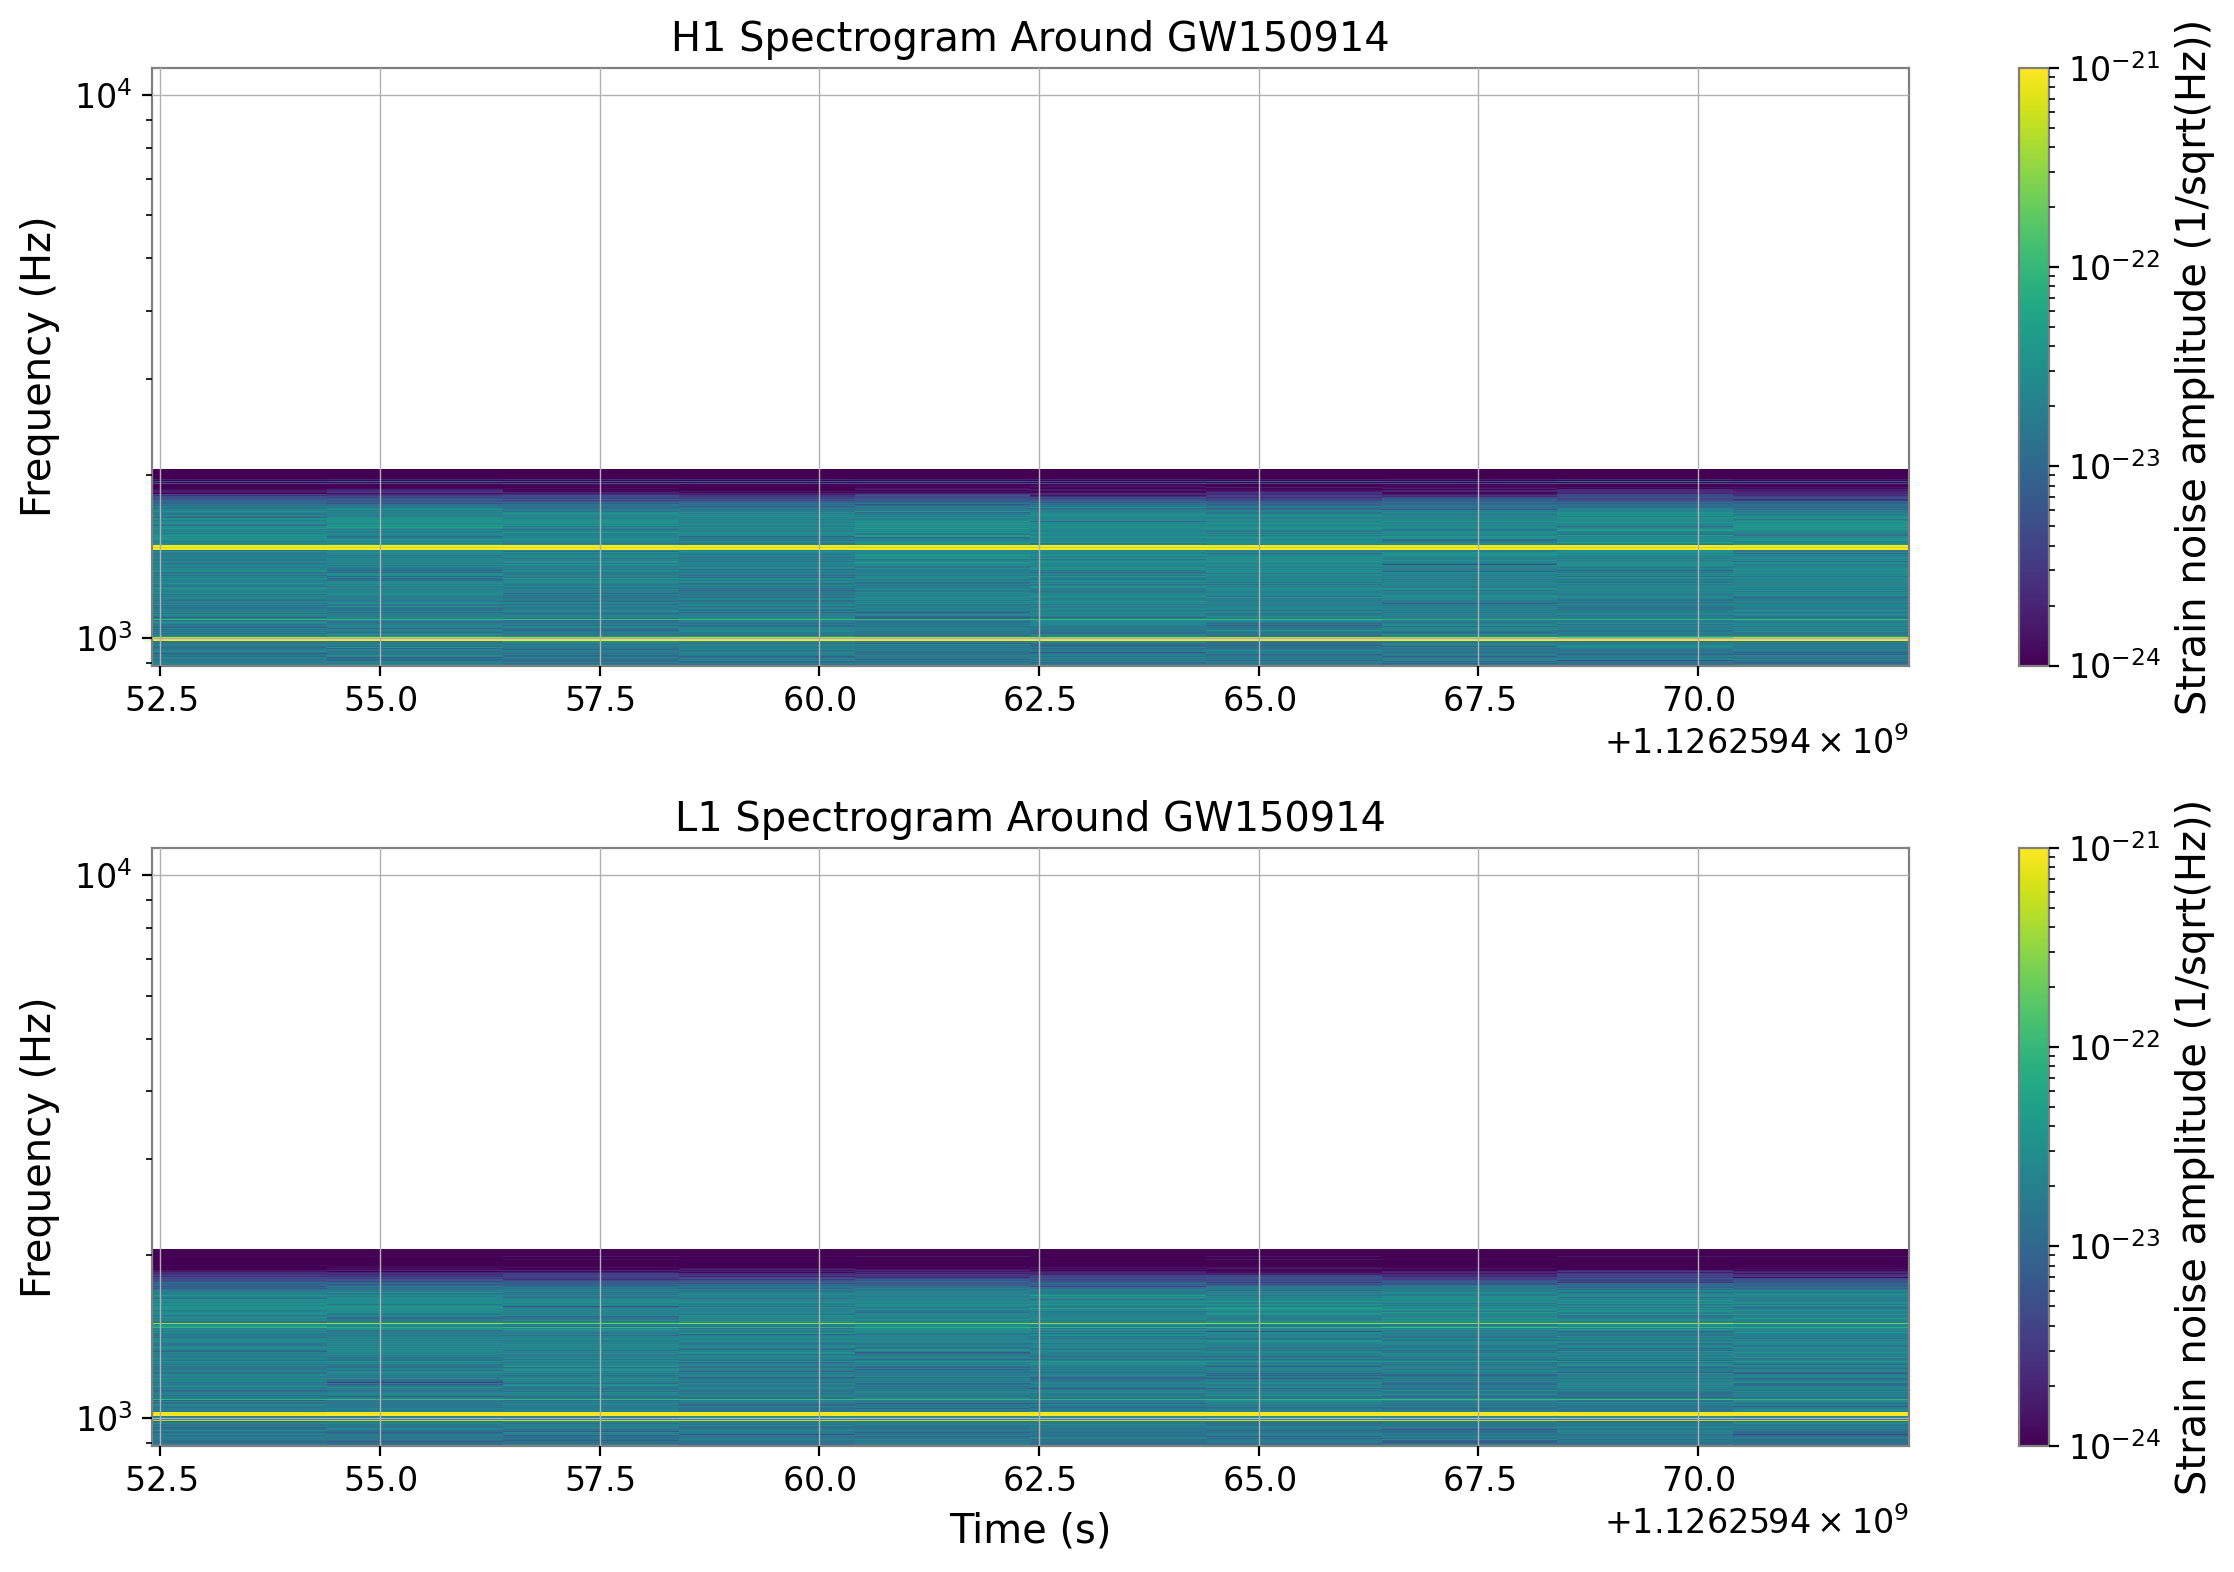

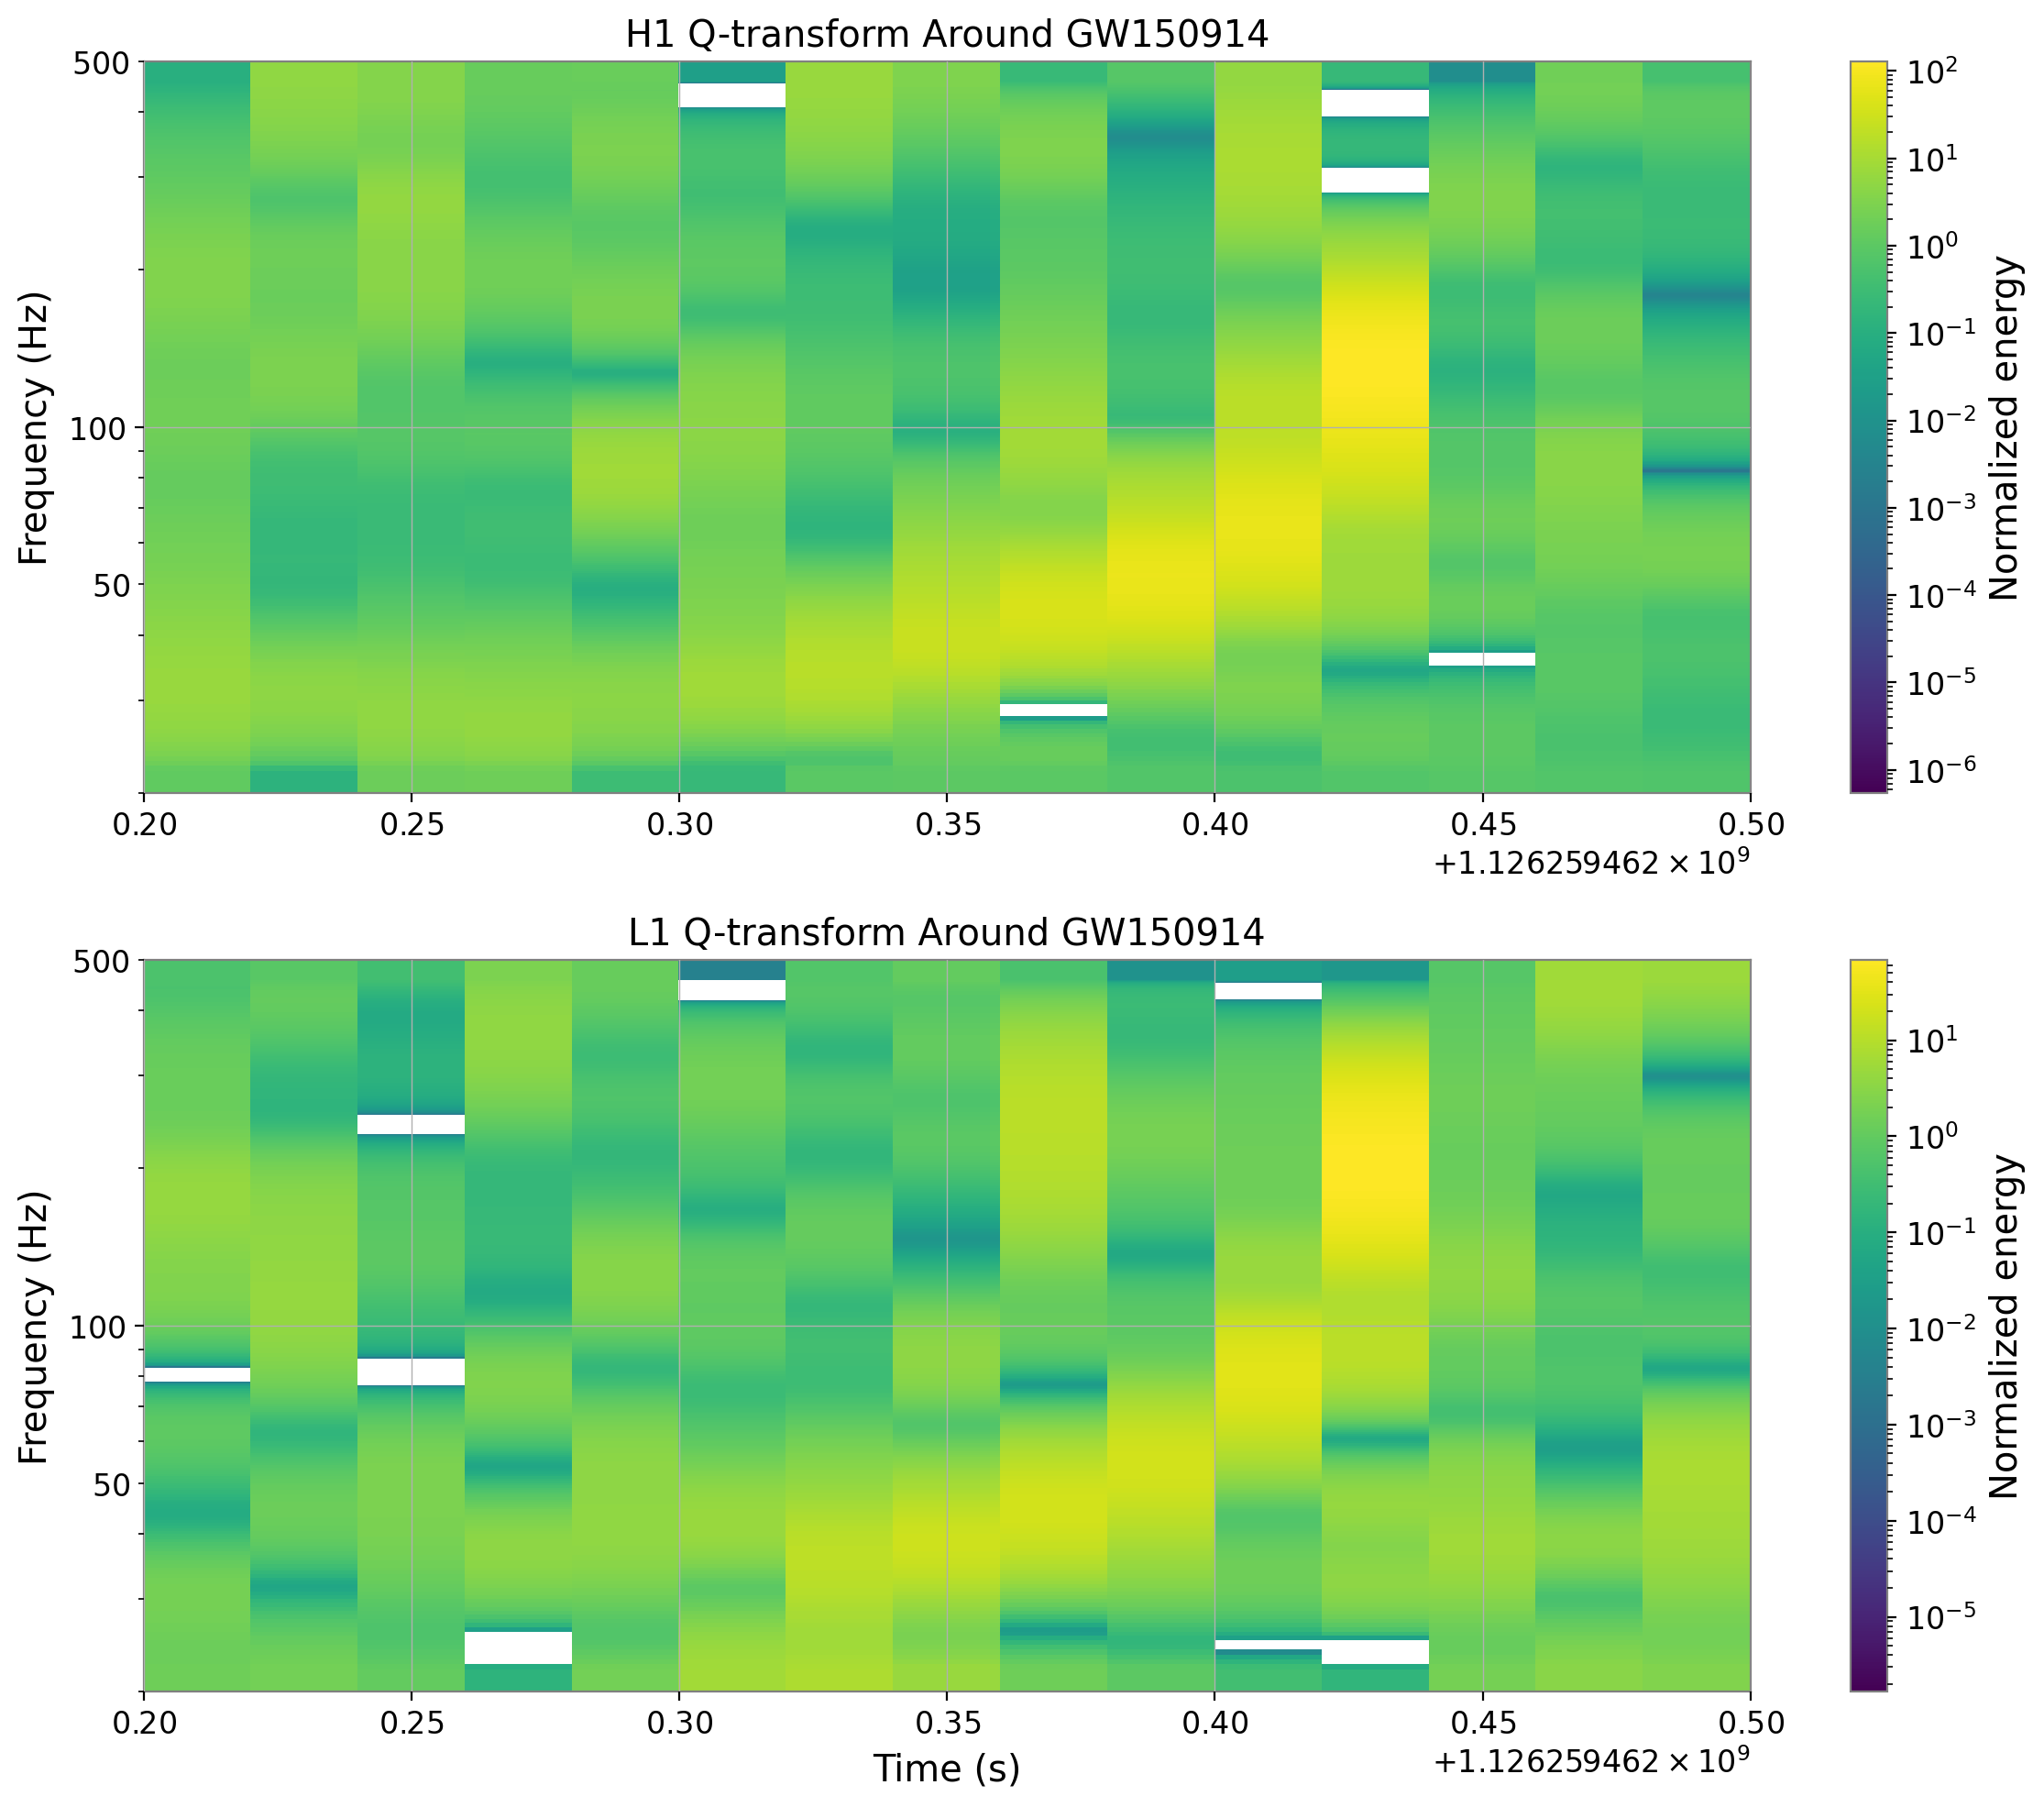

Estimated Signal-to-Noise Ratio (SNR): 1.04


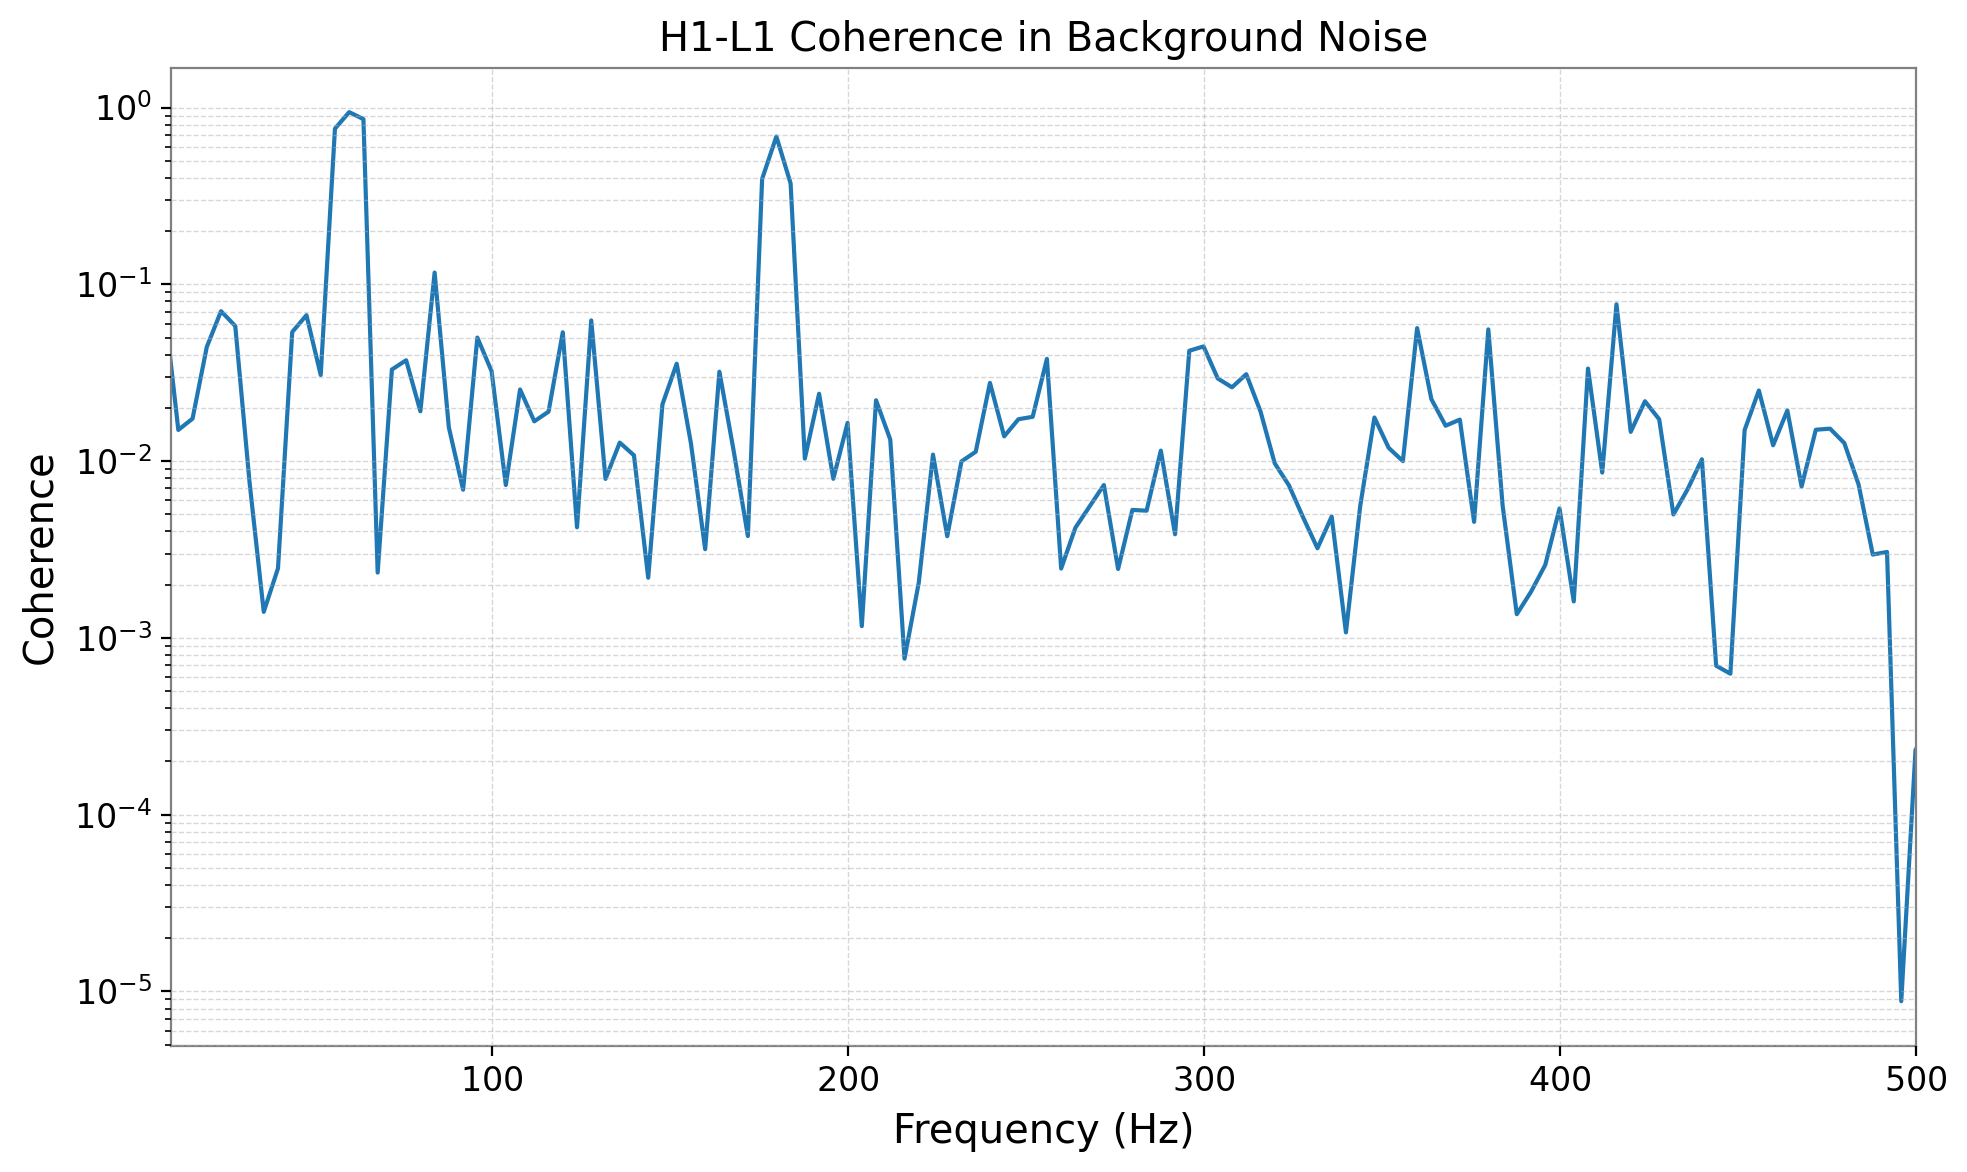

Frequencies with high detector coherence (potential common noise sources):
  56.0 Hz
  60.0 Hz
  64.0 Hz
  180.0 Hz


In [68]:
# Using the previously loaded strain data
# Make sure strain_H1 and strain_L1 are already loaded

# Calculate the power spectral density (PSD) to analyze the background
deltat_bg = 32  # Using a longer segment for better frequency resolution

# Set time window for background analysis (before the event)
bg_start = t0 - deltat_bg
bg_end = t0 - 1  # Ending 1 second before the event

# Crop data to background period
bg_H1 = strain_H1.crop(bg_start, bg_end)
bg_L1 = strain_L1.crop(bg_start, bg_end)

# Calculate PSDs using Welch's method
fftlength = 4  # length of FFT in seconds
overlap = fftlength / 2  # 50% overlap for better averaging

psd_H1 = bg_H1.psd(fftlength=fftlength, overlap=overlap)
psd_L1 = bg_L1.psd(fftlength=fftlength, overlap=overlap)

# Calculate amplitude spectral density (ASD) - square root of PSD
asd_H1 = psd_H1**0.5
asd_L1 = psd_L1**0.5

# Plot the background ASDs
plt.figure(figsize=(12, 8))
plt.loglog(asd_H1.frequencies.value, asd_H1.value, 'b-', label='H1 Background')
plt.loglog(asd_L1.frequencies.value, asd_L1.value, 'r-', label='L1 Background')

# Annotate known sources of noise
plt.annotate('Seismic noise', xy=(20, 1e-22), xytext=(20, 5e-22),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))
             
plt.annotate('Thermal noise', xy=(100, 8e-24), xytext=(100, 3e-23),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))
             
plt.annotate('Quantum noise', xy=(500, 5e-23), xytext=(500, 1e-22),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Strain noise amplitude (1/sqrt(Hz))')
plt.title('LIGO Background Gravitational Wave Noise')
plt.xlim(10, 2000)
plt.ylim(1e-24, 1e-21)
plt.legend()
plt.tight_layout()
plt.savefig('GW_background.png', dpi=300)
plt.show()

# Calculate spectrograms
specgram_H1 = strain_H1.spectrogram(2, fftlength=1, overlap=0.5) ** 0.5
specgram_L1 = strain_L1.spectrogram(2, fftlength=1, overlap=0.5) ** 0.5

# Let's use a more direct approach with matplotlib
plt.figure(figsize=(12, 8))

# Plot H1 spectrogram
ax1 = plt.subplot(2, 1, 1)
# Convert data for manual plotting
times_H1 = specgram_H1.times.value
freqs_H1 = specgram_H1.frequencies.value
data_H1 = specgram_H1.value.T  # transpose for correct orientation

# Create mesh for pcolormesh
times_mesh_H1, freqs_mesh_H1 = np.meshgrid(
    np.append(times_H1, times_H1[-1] + (times_H1[1] - times_H1[0])),
    np.append(freqs_H1, freqs_H1[-1] + (freqs_H1[1] - freqs_H1[0]))
)

# Plot with pcolormesh
mesh_H1 = ax1.pcolormesh(times_mesh_H1, freqs_mesh_H1, data_H1, 
                         norm=LogNorm(vmin=1e-24, vmax=1e-21), 
                         cmap='viridis')
plt.colorbar(mesh_H1, ax=ax1, label='Strain noise amplitude (1/sqrt(Hz))')
ax1.set_yscale('log')
ax1.set_title('H1 Spectrogram Around GW150914')
ax1.set_ylabel('Frequency (Hz)')
ax1.set_xlim(t0 - deltat, t0 + deltat)  # Center on event time

# Plot L1 spectrogram
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
# Convert data for manual plotting
times_L1 = specgram_L1.times.value
freqs_L1 = specgram_L1.frequencies.value
data_L1 = specgram_L1.value.T  # transpose for correct orientation

# Create mesh for pcolormesh
times_mesh_L1, freqs_mesh_L1 = np.meshgrid(
    np.append(times_L1, times_L1[-1] + (times_L1[1] - times_L1[0])),
    np.append(freqs_L1, freqs_L1[-1] + (freqs_L1[1] - freqs_L1[0]))
)

# Plot with pcolormesh
mesh_L1 = ax2.pcolormesh(times_mesh_L1, freqs_mesh_L1, data_L1, 
                         norm=LogNorm(vmin=1e-24, vmax=1e-21), 
                         cmap='viridis')
plt.colorbar(mesh_L1, ax=ax2, label='Strain noise amplitude (1/sqrt(Hz))')
ax2.set_yscale('log')
ax2.set_title('L1 Spectrogram Around GW150914')
ax2.set_ylabel('Frequency (Hz)')
ax2.set_xlabel('Time (s)')
ax2.set_xlim(t0 - deltat, t0 + deltat)  # Center on event time

plt.tight_layout()
plt.savefig('GW_spectrograms.png', dpi=300)
plt.show()

# Try a more direct approach for Q-transform visualization
try:
    # Calculate Q-transforms - this is more computationally intensive
    q_H1 = strain_H1.q_transform(frange=(20, 500), qrange=(4, 100))
    q_L1 = strain_L1.q_transform(frange=(20, 500), qrange=(4, 100))
    
    # Use matplotlib directly instead of gwpy's plotting
    plt.figure(figsize=(12, 10))
    
    # H1 Q-transform
    ax1 = plt.subplot(2, 1, 1)
    # Extract data for plotting
    q_times_H1 = q_H1.times.value
    q_freqs_H1 = q_H1.frequencies.value
    q_data_H1 = q_H1.value.T
    
    # Create mesh grid
    q_times_mesh_H1, q_freqs_mesh_H1 = np.meshgrid(
        np.append(q_times_H1, q_times_H1[-1] + (q_times_H1[1] - q_times_H1[0])),
        np.append(q_freqs_H1, q_freqs_H1[-1] + (q_freqs_H1[1] - q_freqs_H1[0]))
    )
    
    # Plot
    q_mesh_H1 = ax1.pcolormesh(q_times_mesh_H1, q_freqs_mesh_H1, q_data_H1, 
                              norm=LogNorm(), cmap='viridis')
    plt.colorbar(q_mesh_H1, ax=ax1, label='Normalized energy')
    ax1.set_yscale('log')
    ax1.set_title('H1 Q-transform Around GW150914')
    ax1.set_ylabel('Frequency (Hz)')
    ax1.set_xlim(t0 - 0.2, t0 + 0.1)  # Focus on the event
    
    # L1 Q-transform
    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    # Extract data for plotting
    q_times_L1 = q_L1.times.value
    q_freqs_L1 = q_L1.frequencies.value
    q_data_L1 = q_L1.value.T
    
    # Create mesh grid
    q_times_mesh_L1, q_freqs_mesh_L1 = np.meshgrid(
        np.append(q_times_L1, q_times_L1[-1] + (q_times_L1[1] - q_times_L1[0])),
        np.append(q_freqs_L1, q_freqs_L1[-1] + (q_freqs_L1[1] - q_freqs_L1[0]))
    )
    
    # Plot
    q_mesh_L1 = ax2.pcolormesh(q_times_mesh_L1, q_freqs_mesh_L1, q_data_L1, 
                              norm=LogNorm(), cmap='viridis')
    plt.colorbar(q_mesh_L1, ax=ax2, label='Normalized energy')
    ax2.set_yscale('log')
    ax2.set_title('L1 Q-transform Around GW150914')
    ax2.set_ylabel('Frequency (Hz)')
    ax2.set_xlabel('Time (s)')
    
    plt.tight_layout()
    plt.savefig('GW_qtransforms.png', dpi=300)
    plt.show()
except Exception as e:
    print(f"Q-transform visualization failed: {e}")
    print("Continuing with the rest of the analysis...")

# Estimate the signal-to-noise ratio (SNR)
filtered_signal_H1 = strain_H1_filt.crop(t0-0.2, t0+0.1)
filtered_bg_H1 = bg_H1.bandpass(35, 350)

signal_rms = np.sqrt(np.mean(filtered_signal_H1.value**2))
noise_rms = np.sqrt(np.mean(filtered_bg_H1.value**2))
snr = signal_rms / noise_rms

print(f"Estimated Signal-to-Noise Ratio (SNR): {snr:.2f}")

# Additional analysis - coherence between detectors
# This can help identify common signals in the background
try:
    from scipy import signal as sig
    
    # Use a segment before the merger for background analysis
    bg_duration = 8  # seconds
    bg_H1_seg = strain_H1.crop(t0 - bg_duration - 2, t0 - 2)
    bg_L1_seg = strain_L1.crop(t0 - bg_duration - 2, t0 - 2)
    
    # Calculate coherence
    f, Cxy = sig.coherence(bg_H1_seg.value, bg_L1_seg.value, 
                           fs=bg_H1_seg.sample_rate.value,
                           nperseg=1024)
    
    # Plot coherence
    plt.figure(figsize=(10, 6))
    plt.semilogy(f, Cxy)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Coherence')
    plt.title('H1-L1 Coherence in Background Noise')
    plt.xlim(10, 500)
    plt.tight_layout()
    plt.savefig('GW_coherence.png', dpi=300)
    plt.show()
    
    # Highlight frequencies with high coherence
    high_coh_mask = Cxy > 0.5
    if np.any(high_coh_mask):
        high_coh_freqs = f[high_coh_mask]
        print(f"Frequencies with high detector coherence (potential common noise sources):")
        for freq in high_coh_freqs:
            print(f"  {freq:.1f} Hz")
    else:
        print("No frequencies with particularly high coherence were found.")
    
except Exception as e:
    print(f"Coherence analysis failed: {e}")